# Wilson loop and Green's function formalism

The Berry curvature along a k-path can be computed with two independent algorithms:
`mode="Wilson"` (a lattice gauge-invariant product of overlaps between neighboring occupied-band
projectors) and `mode="Green"` (a Green's-function/Kubo-type formula built from
$\partial_k H$). `topology.write_berry` scans a k-path with either method, and the two should
agree wherever both are numerically well-converged, giving an independent cross-check of the same
underlying Berry curvature.

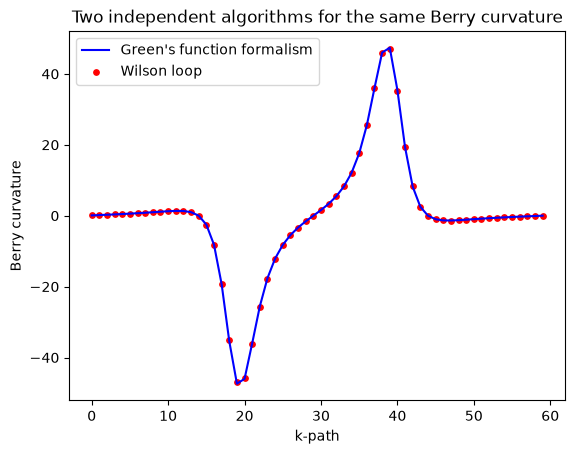

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology

g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False)
h.add_sublattice_imbalance(0.6)

(x1,y1) = topology.write_berry(h,mode="Wilson",nk=60)
(x,y) = topology.write_berry(h,mode="Green",nk=60)

plt.plot(x,y,c="blue",label="Green's function formalism")
plt.scatter(x1,y1,c="red",s=15,label="Wilson loop")
plt.xlabel("k-path") ; plt.ylabel("Berry curvature")
plt.legend()
plt.title("Two independent algorithms for the same Berry curvature")
plt.show()

### The same comparison over the whole Brillouin zone
The comparison can be done over the whole Brillouin zone as well, with `h.get_berry_curvature()`,
which takes the same `mode`. For the gapped honeycomb lattice the curvature sits at the two valleys
with opposite signs, so that the Chern number vanishes, and the two algorithms give the same map.

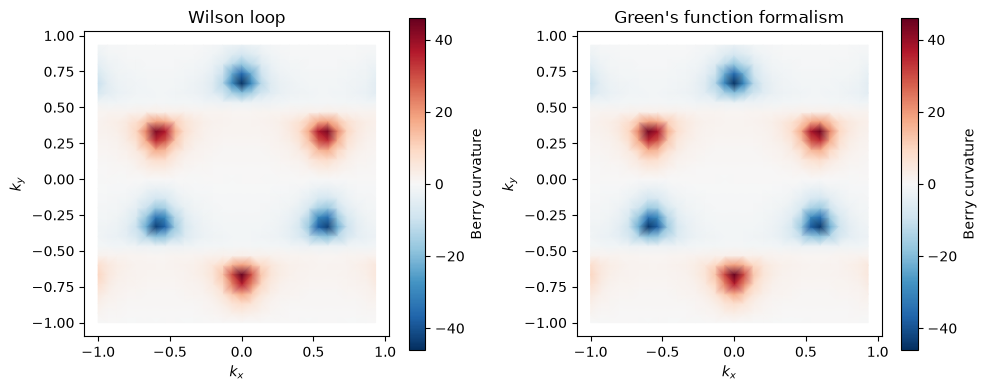

In [2]:
(kx1,ky1,b1) = h.get_berry_curvature(nk=30,mode="Wilson",write=False) # Wilson loop map
(kx2,ky2,b2) = h.get_berry_curvature(nk=30,mode="Green",write=False) # Green's function map

vm = np.max(np.abs(b1)) # symmetric color scale
fig,axs = plt.subplots(1,2,figsize=(10,4))
s = axs[0].tripcolor(kx1,ky1,b1,cmap="RdBu_r",shading="gouraud",vmin=-vm,vmax=vm)
fig.colorbar(s,ax=axs[0],label="Berry curvature")
axs[0].set_title("Wilson loop")
s = axs[1].tripcolor(kx2,ky2,b2,cmap="RdBu_r",shading="gouraud",vmin=-vm,vmax=vm)
fig.colorbar(s,ax=axs[1],label="Berry curvature")
axs[1].set_title("Green's function formalism")
for ax in axs:
    ax.set_aspect("equal") ; ax.set_xlabel("$k_x$") ; ax.set_ylabel("$k_y$")
plt.tight_layout()
plt.show()